# Multiworm Feature Extraction

## Notebook Setup
In this section, we'll set ourselves up for success by setting up our Python environment appropriately, importing the Python libraries we'll be using, and downloading the raw data from Google Drive.

In [1]:
# Importing the necessary Python libraries
from __future__ import annotations

import json
import math
import os
import pickle
import shutil
import zipfile
from pathlib import Path

import cv2
import gdown
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import skimage
import tifffile
import torch
from PIL import Image
from scipy.ndimage import convolve, binary_fill_holes
from skimage.measure import label
from skimage.morphology import skeletonize, remove_small_objects
from transformers import pipeline, AutoImageProcessor, AutoModelForImageClassification

In [2]:
# Setting the root of the working directory
WORK_DIR_ROOT = '..'

# Setting the working directories used throughout this notebook
raw_files_dir = f'{WORK_DIR_ROOT}/data/raw_files'
processed_files_dir = f'{WORK_DIR_ROOT}/data/processed_files/multiworm_feature_extraction'
processed_base_images_files_dir = f'{processed_files_dir}/base_images'
final_cutouts_dir = Path(processed_files_dir) / 'final_cutouts'
metrics_output_dir = Path(processed_files_dir) / 'metrics'

# Creating required directories (if not already created)
os.makedirs(raw_files_dir, exist_ok=True)
os.makedirs(processed_base_images_files_dir, exist_ok=True)
final_cutouts_dir.mkdir(parents=True, exist_ok=True)
metrics_output_dir.mkdir(parents=True, exist_ok=True)

## Downloading the Raw TIFF Files

In [3]:
# Setting the raw Google Drive doc ID and file URL
RAW_FILE_DOC_ID = '1UTYRcgheRP1eMXw71CNgh9-em2MigdDb'
gdrive_file_url = f'https://drive.google.com/uc?id={RAW_FILE_DOC_ID}'

# Checking whether raw files are already present (ignoring .gitkeep)
existing_raw_files = [
    path for path in Path(raw_files_dir).iterdir() if path.name != '.gitkeep'
 ]

# Downloading and extracting only when the raw files directory is empty or only has .gitkeep
if not existing_raw_files:

    # Downloading the raw files from Google Drive
    gdown.download(
        url = gdrive_file_url,
        output = f'{raw_files_dir}/samples.zip'
    )

    # Setting the .zip filepath
    zip_path = Path(f'{raw_files_dir}/samples.zip')

    # Setting the prefix associated to all the raw TIF files
    RAW_FILE_PREFIX = "06.27.25 CONFOCAL VID_DYS1AH DAY 5 CRAWL "

    # Interacting with the ZIP file downloaded from Google Drive
    with zipfile.ZipFile(zip_path) as z:

        # Iterating over each TIF file in the raw ZIP
        for member in z.namelist():

            # Checking if the file is in the "sample images/" directory and ends with ".tif"
            if member.startswith('sample images/') and member.endswith('.tif'):

                # Getting the original name of the file
                original_name = Path(member).name

                # Setting a new name for the file by stripping the prefix from the file
                new_name = original_name.replace(RAW_FILE_PREFIX, '', 1)

                # Extracting the contents of the file from the ZIP
                target = zip_path.parent / new_name
                with z.open(member) as src, open(target, 'wb') as destination:
                    destination.write(src.read())

    # Deleting the original ZIP file as it is no longer needed
    zip_path.unlink()
else:
    print('Raw files already exist in raw_files_dir; skipping download and extraction.')

Raw files already exist in raw_files_dir; skipping download and extraction.


## Processing the TIFFs into JPEGs
Now that we have downloaded the raw TIFF files from Google Drive, we need to process them into JPEG image files.

In [4]:
# Checking whether processed images are already present (ignoring .gitkeep)
existing_processed_files = [
    path for path in Path(processed_base_images_files_dir).iterdir() if path.name != '.gitkeep'
 ]

# Processing raw TIFF files only when the processed directory is empty or only has .gitkeep
if not existing_processed_files:

    # Iterating over all the raw files
    for raw_file_name in os.listdir(raw_files_dir):

        # Skipping any files that don't end in ".tif"
        if not raw_file_name.endswith('.tif'):
            continue

        # Loading the contents of the TIFF file as a numpy array
        tiff_path = os.path.join(raw_files_dir, raw_file_name)
        img_array = tifffile.imread(tiff_path)

        # Normalizing TIFFs into a frame-first iterable so both single-frame and multi-frame work
        if img_array.ndim == 2:
            frames = [img_array]
        elif img_array.ndim == 3:
            # Typical stack format: (num_frames, height, width)
            frames = [img_array[frame_idx] for frame_idx in range(img_array.shape[0])]
        else:
            # Skipping unsupported dimensions (for example, volumetric TIFFs)
            print(f'Skipping {raw_file_name}: unsupported TIFF dimensions {img_array.shape}')
            continue

        # Iterating over each frame and exporting to JPEG
        raw_file_stem = Path(raw_file_name).stem
        for frame_idx, frame in enumerate(frames):
            frame = np.asarray(frame)

            # Extracting min/max values for frame-level normalization
            frame_min = frame.min()
            frame_max = frame.max()

            # Handling constant-value frames safely
            if frame_max == frame_min:
                frame_8bit = np.zeros_like(frame, dtype=np.uint8)
            else:
                frame_adjusted = frame - frame_min
                scaling_factor = 255.0 / (frame_max - frame_min)
                frame_8bit = (frame_adjusted * scaling_factor).astype(np.uint8)

            # Producing and saving the JPEG image
            img = Image.fromarray(frame_8bit)
            if len(frames) == 1:
                dest_file_name = f'{raw_file_stem}.jpg'
            else:
                dest_file_name = f'{raw_file_stem}_f{frame_idx:04d}.jpg'

            dest_location = os.path.join(processed_base_images_files_dir, dest_file_name)
            img.save(fp=dest_location, format='JPEG', quality=95)
else:
    print('Processed images already exist in processed_base_images_files_dir; skipping TIFF-to-JPEG conversion.')

### Loading Test Image

Using test image: 5_t065_ch01.jpg


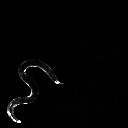

In [5]:
# Loading a test image from file
preferred_test_stem = '5_t065_ch01'
candidate_test_images = sorted(Path(processed_base_images_files_dir).glob(f'{preferred_test_stem}*.jpg'))

if candidate_test_images:
    test_image_path = candidate_test_images[0]
else:
    fallback_images = sorted(Path(processed_base_images_files_dir).glob('*.jpg'))
    if not fallback_images:
        raise FileNotFoundError(
            f'No JPEG files found in processed directory: {processed_base_images_files_dir}'
        )
    test_image_path = fallback_images[0]

raw_image = cv2.imread(str(test_image_path))

if raw_image is None:
    raise FileNotFoundError(f'Could not load test image: {test_image_path}')

# Using the selected image stem as the subdirectory name for cutouts
source_file_stem = test_image_path.stem
print(f'Using test image: {test_image_path.name}')
Image.fromarray(cv2.cvtColor(raw_image, cv2.COLOR_BGR2RGB))

## Getting Non-Edge Masks

### Loading the SAM2 Model Artifacts

In [6]:
# Setting the hardware we are working on
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Current hardware device type: {device}')

# Loading the mask generating pipeline from Hugging Face
mask_generator = pipeline('mask-generation', model = 'facebook/sam2.1-hiera-large', device = device)

Current hardware device type: mps


Loading weights:   0%|          | 0/741 [00:00<?, ?it/s]

### Creating Helper Functions to Produce Non-Edge Masks

In [7]:
# Checking whether a bounding box touches any image boundary
def _is_on_edge(x, y, w, h, img_width, img_height):
    # Checking the left edge
    if x <= 0:
        return True

    # Checking the top edge
    if y <= 0:
        return True

    # Checking the right edge
    if (x + w) >= img_width - 1:
        return True

    # Checking the bottom edge
    if (y + h) >= img_height - 1:
        return True

    # Returning False if no edge was touched
    return False

# Determining the valid microscope imaging area from an RGB/grayscale image
def get_valid_imaging_area(image, margin=5, max_iterations=100):
    # Converting to grayscale if the input has 3 channels
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        gray = image

    # Binarizing the image using Otsu thresholding
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Finding external contours in the binary image
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Falling back to full-image valid area when no contours exist
    if not contours:
        return np.ones_like(gray, dtype=bool), False

    # Keeping only contours in a plausible area range
    valid_contours = [
        cnt for cnt in contours
        if 0.1 < cv2.contourArea(cnt) / (gray.shape[0] * gray.shape[1]) < 0.99
    ]

    # Falling back to full-image valid area when no plausible contour exists
    if not valid_contours:
        return np.ones_like(gray, dtype=bool), False

    # Selecting the largest valid contour as the imaging field
    largest_contour = max(valid_contours, key=cv2.contourArea)

    # Drawing the valid area as a binary mask
    valid_area_mask = np.zeros_like(gray, dtype=np.uint8)
    cv2.drawContours(valid_area_mask, [largest_contour], -1, 255, -1)

    # Eroding the valid area by 'margin' pixels to avoid edge artifacts
    if margin > 0:
        kernel = np.ones((3, 3), np.uint8)
        eroded_mask = valid_area_mask.copy()

        # Applying erosion iteratively with a safety stop
        for _ in range(min(margin, max_iterations)):
            temp_mask = cv2.erode(eroded_mask, kernel)
            if np.sum(temp_mask) < 1000:
                break
            eroded_mask = temp_mask

        valid_area_mask = eroded_mask

    # Returning a boolean valid-area mask and success flag
    return valid_area_mask > 0, True

# Producing non-edge masks from the HF mask-generation pipeline output
def get_nonedge_masks_hf(raw_image_bgr, mask_generator, margin=5, **mask_gen_kwargs):

    # Converting OpenCV BGR -> RGB to match model expectations
    image = cv2.cvtColor(raw_image_bgr, cv2.COLOR_BGR2RGB)
    img_height, img_width = image.shape[:2]

    # Converting to PIL image for Hugging Face pipeline input
    pil_image = Image.fromarray(image)

    # Running automatic mask generation
    outputs = mask_generator(image=pil_image, **mask_gen_kwargs)
    raw_masks = outputs.get("masks", [])

    # Normalizing HF mask outputs into boolean segmentation arrays
    segmentations = []
    for mask in raw_masks:
        # Handling tensor mask outputs
        if isinstance(mask, torch.Tensor):
            segmentation = mask.detach().cpu().numpy().astype(bool)

        # Handling PIL mask outputs
        elif isinstance(mask, Image.Image):
            segmentation = (np.array(mask) > 0)

        # Handling numpy/other array-like outputs
        else:
            segmentation = np.asarray(mask).astype(bool)

        # Keeping only masks that match the input image shape
        if segmentation.shape == (img_height, img_width):
            segmentations.append(segmentation)

    # Computing the valid imaging area used for edge filtering
    valid_area, success = get_valid_imaging_area(image, margin=margin)
    nonedge_masks = []

    # Preferred path: keep masks fully contained in valid imaging area
    if success:
        for segmentation in segmentations:
            if np.all(segmentation * valid_area == segmentation):
                nonedge_masks.append(segmentation)

    # Fallback path: remove masks that touch the image boundary
    else:
        for segmentation in segmentations:
            coords = np.where(segmentation)
            if len(coords[0]) == 0:
                continue

            # Computing bounding box around the mask
            y1, x1 = np.min(coords[0]), np.min(coords[1])
            y2, x2 = np.max(coords[0]), np.max(coords[1])
            h, w = (y2 - y1 + 1), (x2 - x1 + 1)

            # Keeping only masks whose bounding box is not on image edges
            if not _is_on_edge(x1, y1, w, h, img_width, img_height):
                nonedge_masks.append(segmentation)

    # Printing a compact debug summary of filtering behavior
    print(f"Mask debug: raw={len(segmentations)}, valid_area_success={success}, kept={len(nonedge_masks)}")

    # Returning outputs aligned with get_nonedge_masks(...) in the script
    return image, img_height, img_width, nonedge_masks

### Producing / Saving the Non-Edge Masks

In [8]:
# Preparing the cutout directory for this source image
cutouts_root_dir = Path(processed_files_dir) / 'cutouts'
image_cutouts_dir = cutouts_root_dir / source_file_stem

# Always generating non-edge masks for the current notebook session so downstream cells
# have image, size, and mask variables available even if cutouts already exist on disk
image, img_height, img_width, nonedge_masks = get_nonedge_masks_hf(
    raw_image_bgr=raw_image,
    mask_generator=mask_generator,
    margin=5,
    points_per_batch=64,
    pred_iou_thresh=0.85,
    stability_score_thresh=0.85,
    stability_score_offset=0.85,
)

print(f"Image shape: {image.shape}, height={img_height}, width={img_width}")
print(f"Non-edge masks: {len(nonedge_masks)}")

Mask debug: raw=2, valid_area_success=False, kept=1
Image shape: (128, 128, 3), height=128, width=128
Non-edge masks: 1


In [9]:
# Saving each non-edge mask as a cropped JPEG cutout
def save_mask_cutouts(image, nonedge_masks, output_dir: Path):
    # Refreshing the output directory so each run starts clean
    if output_dir.exists():
        shutil.rmtree(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    print(f"Saving {len(nonedge_masks)} non-edge cutouts to {output_dir}")

    for i, mask in enumerate(nonedge_masks):
        
        # Getting bounding box coordinates from the mask pixel positions
        coords = np.where(mask)
        y1, x1 = np.min(coords[0]), np.min(coords[1])
        y2, x2 = np.max(coords[0]), np.max(coords[1])

        # Expanding the 2D boolean mask to 3 channels so it can be applied to an RGB image
        mask_3d = np.repeat(mask[:, :, np.newaxis], 3, axis=2)

        # Zeroing out all pixels outside the mask, then cropping to the tight bounding box
        cutout = image * mask_3d
        cutout = cutout[y1:y2+1, x1:x2+1]

        # Saving the cropped cutout as a JPEG (converting back to BGR for OpenCV)
        cutout_path = output_dir / f"{i}.jpg"
        cv2.imwrite(str(cutout_path), cv2.cvtColor(cutout, cv2.COLOR_RGB2BGR))

# Refreshing cutouts so they stay aligned with the current non-edge masks
save_mask_cutouts(image, nonedge_masks, image_cutouts_dir)

Saving 1 non-edge cutouts to ../data/processed_files/multiworm_feature_extraction/cutouts/5_t065_ch01


## Classifying the Worm with Lilly Guisnet's Custom Classifier

In [10]:
# Setting the Hugging Face repo for the classifier model
# (Note: This model was created by Lilly Guisnet and fine-tuned on C. elegans images)
HF_CLASSIFIER_REPO = 'lillyguisnet/celegans-classifier-vit-h-14-finetuned'

# Loading the custom image processor / image classifier from Hugging Face
image_classification_processor = AutoImageProcessor.from_pretrained(HF_CLASSIFIER_REPO)
image_classification_model = AutoModelForImageClassification.from_pretrained(HF_CLASSIFIER_REPO)

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/520 [00:00<?, ?it/s]

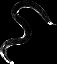

In [11]:
# Loading a cutout from this source image's output directory
cutout = Image.open(image_cutouts_dir / '0.jpg')
cutout

In [12]:
# Classifying all saved cutouts for this single test image
classifications = []

for i in range(len(nonedge_masks)):
    cutout_path = image_cutouts_dir / f'{i}.jpg'
    cutout = Image.open(cutout_path).convert('RGB')

    inputs = image_classification_processor(images=cutout, return_tensors='pt')

    with torch.no_grad():
        outputs = image_classification_model(**inputs)######ddasdf####
    logits = outputs.logits

    pred = logits.argmax(-1).item()
    classifications.append('worm_any' if pred == 1 else 'notworm')

print(f'Classified cutouts: {len(classifications)}')
print(classifications)

Classified cutouts: 1
['worm_any']


## Merging and Cleaning Worm Masks
Now we classify all generated cutouts, keep only masks predicted as worms, merge near-duplicate overlaps, and clean each mask before downstream metric extraction.

In [13]:
# Merging and cleaning worm masks (mirrors script logic)
def merge_and_clean_worm_masks(classifications, nonedge_masks, overlap_threshold=0.95, min_area=25):
    """
    Merge overlapping worm masks and clean results by removing small regions,
    removing masks with holes, and keeping only the largest connected component.
    """
    worm_masks = []
    for i, classification in enumerate(classifications):
        if classification == "worm_any":
            worm_masks.append(nonedge_masks[i])

    if worm_masks:
        merged_masks = []
        final_masks = []

        for i in range(len(worm_masks)):
            if i in merged_masks:
                continue

            current_mask = worm_masks[i]
            current_area = np.sum(current_mask)
            for j in range(i + 1, len(worm_masks)):
                if j in merged_masks:
                    continue

                other_mask = worm_masks[j]
                overlap = np.sum(current_mask & other_mask)
                overlap_ratio = overlap / min(current_area, np.sum(other_mask))

                if overlap_ratio > overlap_threshold:
                    current_mask = current_mask | other_mask
                    current_area = np.sum(current_mask)
                    merged_masks.append(j)

            final_masks.append(current_mask)

        worm_masks = []
        for i, mask in enumerate(final_masks):
            if np.sum(mask) >= min_area:
                contours, hierarchy = cv2.findContours(
                    (mask * 255).astype(np.uint8),
                    cv2.RETR_TREE,
                    cv2.CHAIN_APPROX_SIMPLE,
                )

                has_holes = False
                if hierarchy is not None:
                    hierarchy = hierarchy[0]
                    for h in hierarchy:
                        if h[3] >= 0:
                            has_holes = True
                            print(f"Skipping mask {i} due to holes in the mask")
                            break

                if not has_holes:
                    num_labels, labels = cv2.connectedComponents(mask.astype(np.uint8))
                    if num_labels > 2:
                        unique_labels, label_counts = np.unique(labels[labels != 0], return_counts=True)
                        largest_label = unique_labels[np.argmax(label_counts)]
                        mask = (labels == largest_label).astype(np.uint8)

                    worm_masks.append(mask)

        num_distinct_worms = len(worm_masks)
        print(f"Number of distinct worm regions: {num_distinct_worms}")
    else:
        num_distinct_worms = 0

    return worm_masks, num_distinct_worms

In [14]:
# Applying merge/clean to the current image's classified candidate masks
required_vars = [
    "nonedge_masks",
    "classifications",
]
missing_vars = [name for name in required_vars if name not in globals()]
if missing_vars:
    raise RuntimeError(
        "Missing required notebook variables: "
        + ", ".join(missing_vars)
        + ". Re-run the prior cells that generate masks and classify the cutouts."
    )

worm_masks, num_distinct_worms = merge_and_clean_worm_masks(
    classifications=classifications,
    nonedge_masks=nonedge_masks,
    overlap_threshold=0.95,
    min_area=25,
)

print(f"Classified candidates: {len(classifications)}")
print(f"Worm masks after merge/clean: {num_distinct_worms}")

Number of distinct worm regions: 1
Classified candidates: 1
Worm masks after merge/clean: 1


## Extracting Worm Metrics
With cleaned worm masks for the current test image, we can now measure each detected worm's area, perimeter, and medial-axis-derived width and length features.

In [15]:
# Filtering out abnormally small worms relative to the image-level mean area
def filter_worms(allworms_metrics, threshold):
    if not allworms_metrics:
        return []

    area_values = [worm["area"] for worm in allworms_metrics]
    area_mean = float(np.mean(area_values)) if area_values else 0.0
    if area_mean <= 0:
        return []

    filtered_metrics = []
    for worm in allworms_metrics:
        if worm["area"] > threshold * area_mean:
            filtered_metrics.append(worm)
    return filtered_metrics


# Extracting per-worm shape metrics from cleaned masks
def extract_worm_metrics(worm_masks, img_path, img_height, img_width, threshold=0.75):
    img_id = Path(img_path).stem
    allworms_metrics = []

    for i, npmask in enumerate(worm_masks):
        print(f"Processing worm {i}")

        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
            (npmask * 255).astype(np.uint8),
            connectivity=8,
        )
        largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        largest_component_mask = (labels == largest_label).astype(np.uint8)

        area = np.sum(largest_component_mask)
        contours, hierarchy = cv2.findContours(
            (largest_component_mask * 255).astype(np.uint8),
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_NONE,
        )
        perimeter = cv2.arcLength(contours[0], True)

        medial_axis, distance = skimage.morphology.medial_axis(
            largest_component_mask > 0,
            return_distance=True,
        )
        structuring_element = np.array(
            [[1, 1, 1], [1, 10, 1], [1, 1, 1]],
            dtype=np.uint8,
        )
        neighbours = convolve(
            medial_axis.astype(np.uint8),
            structuring_element,
            mode="constant",
            cval=0,
        )
        end_points = np.where(neighbours == 11, 1, 0)
        branch_points = np.where(neighbours > 12, 1, 0)
        labeled_branches = label(branch_points, connectivity=2)
        branch_indices = np.argwhere(labeled_branches > 0)
        end_indices = np.argwhere(end_points > 0)
        indices = np.concatenate((branch_indices, end_indices), axis=0)

        if len(indices) == 0:
            continue

        paths = []
        for start in range(len(indices)):
            for end in range(len(indices)):
                startid = tuple(indices[start])
                endid = tuple(indices[end])
                try:
                    route, weight = skimage.graph.route_through_array(
                        np.invert(medial_axis),
                        startid,
                        endid,
                    )
                except Exception:
                    continue
                length = len(route)
                paths.append([startid, endid, length, route, weight])

        if not paths:
            continue

        longest_length = max(paths, key=lambda x: x[2])
        pruned_mediala = np.zeros((img_height, img_width), dtype=np.uint8)
        for coord in range(len(longest_length[3])):
            pruned_mediala[longest_length[3][coord]] = 1

        medial_axis_distances_sorted = [distance[pt[0], pt[1]] for pt in longest_length[3]]
        medialaxis_length_list = np.arange(0, len(medial_axis_distances_sorted))
        pruned_medialaxis_length = np.sum(pruned_mediala)
        mean_wormwidth = np.mean(medial_axis_distances_sorted)
        mid_length_width = medial_axis_distances_sorted[int(len(medial_axis_distances_sorted) / 2)]

        worm_metrics = {
            "img_id": img_id,
            "worm_id": i,
            "area": area,
            "perimeter": perimeter,
            "medial_axis_distances_sorted": medial_axis_distances_sorted,
            "medialaxis_length_list": np.ndarray.tolist(medialaxis_length_list),
            "pruned_medialaxis_length": pruned_medialaxis_length,
            "mean_wormwidth": mean_wormwidth,
            "mid_length_width": mid_length_width,
            "mask": largest_component_mask,
        }
        allworms_metrics.append(worm_metrics)

    return filter_worms(allworms_metrics, threshold=threshold)

In [16]:
# Applying metric extraction to the cleaned masks from the current test image
required_vars = ["worm_masks", "test_image_path", "img_height", "img_width"]
missing_vars = [name for name in required_vars if name not in globals()]
if missing_vars:
    raise RuntimeError(
        "Missing required notebook variables: "
        + ", ".join(missing_vars)
        + ". Re-run the prior cells that build the cleaned worm masks first."
    )

worm_metrics = extract_worm_metrics(
    worm_masks=worm_masks,
    img_path=str(test_image_path),
    img_height=img_height,
    img_width=img_width,
    threshold=0.75,
)

print(f"Filtered worms with extracted metrics: {len(worm_metrics)}")
if worm_metrics:
    preview = {
        key: value
        for key, value in worm_metrics[0].items()
        if key not in {"mask", "medial_axis_distances_sorted", "medialaxis_length_list"}
    }
    preview

Processing worm 0
Filtered worms with extracted metrics: 1


## Saving Worm Outputs
For the single test image, we will save two artifacts in a script-aligned layout:
- overlay PNGs in a `final_cutouts` folder for quick visual inspection
- a pickle file in a `metrics` folder containing the extracted worm measurements

In [17]:
# Defining save_worms(...) for this notebook flow
def save_worms(allworms_metrics, original_image=None, cutouts_dir: Path = Path('.'), metrics_dir: Path = Path('.')):
    """
    Save filtered worm overlays for visual review and persist metrics as a pickle.
    """
    if not allworms_metrics:
        print('No worm metrics provided')
        return []

    img_id = allworms_metrics[0]['img_id']

    for i, worm in enumerate(allworms_metrics):
        cutout_path = cutouts_dir / f'{img_id}_worm_{i}.png'
        cutout_name = f'{img_id}_worm_{i}'

        if original_image is not None:
            overlay = original_image.copy()
            overlay[worm['mask'] > 0] = [0, 255, 0]

            alpha = 0.4
            blended = cv2.addWeighted(original_image, 1 - alpha, overlay, alpha, 0)

            font = cv2.FONT_HERSHEY_SIMPLEX
            cv2.putText(blended, cutout_name, (10, 30), font, 1, (255, 255, 255), 2)

            cv2.imwrite(str(cutout_path), cv2.cvtColor(blended, cv2.COLOR_RGB2BGR))
        else:
            cv2.imwrite(str(cutout_path), (worm['mask'] * 255).astype(np.uint8))

    metrics_path = metrics_dir / f'{img_id}.pkl'
    with open(metrics_path, 'wb') as file_handle:
        pickle.dump(allworms_metrics, file_handle)

    print(f'Saved {len(allworms_metrics)} worm overlay(s) to {cutouts_dir}')
    print(f'Saved filtered metrics to {metrics_path}')
    return allworms_metrics

In [18]:
# Saving the current test image's filtered worm outputs
required_vars = ['worm_metrics', 'image']
missing_vars = [name for name in required_vars if name not in globals()]
if missing_vars:
    raise RuntimeError(
        'Missing required notebook variables: '
        + ', '.join(missing_vars)
        + '. Re-run the metric extraction cells first.'
    )

saved_worm_metrics = save_worms(
    allworms_metrics=worm_metrics,
    original_image=image,
    cutouts_dir=final_cutouts_dir,
    metrics_dir=metrics_output_dir,
)

print(f'Saved worm records: {len(saved_worm_metrics)}')
print(f'Overlay directory: {final_cutouts_dir}')
print(f'Metrics directory: {metrics_output_dir}')

Saved 1 worm overlay(s) to ../data/processed_files/multiworm_feature_extraction/final_cutouts
Saved filtered metrics to ../data/processed_files/multiworm_feature_extraction/metrics/5_t065_ch01.pkl
Saved worm records: 1
Overlay directory: ../data/processed_files/multiworm_feature_extraction/final_cutouts
Metrics directory: ../data/processed_files/multiworm_feature_extraction/metrics


In [19]:
# Defining a function to determine worm length from a cutout image
def determine_worm_length(image):
    """
    Determine the length of a worm from a cutout image by:
    1. Converting to grayscale and applying thresholding
    2. Finding the largest connected component
    3. Filling holes and removing small objects
    4. Creating a skeleton and graph representation
    5. Finding the longest path between endpoints
    """
    # Converting the original image from BGR to RGB
    rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) if len(image.shape) == 3 and image.shape[2] == 3 else image

    # Converting the original image to grayscale (if needed)
    if len(image.shape) == 3:
        grayscale_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        grayscale_image = image

    # Applying a slight gaussian blur to the grayscale image
    blurred_grayscale_image = cv2.GaussianBlur(grayscale_image, (5, 5), 0)

    # Enhancing local contrast so dim worm pixels are easier to recover
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_grayscale_image = clahe.apply(blurred_grayscale_image)

    # Applying a permissive Otsu threshold on the enhanced image
    otsu_threshold, _ = cv2.threshold(
        enhanced_grayscale_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    _, otsu_binary_image = cv2.threshold(
        enhanced_grayscale_image, int(0.75 * otsu_threshold), 255, cv2.THRESH_BINARY
    )

    # Building a local adaptive mask to recover low-contrast sections
    adaptive_binary_image = cv2.adaptiveThreshold(
        enhanced_grayscale_image,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        31,
        -3,
    )

    # Combining global and local masks
    combined_binary_image = cv2.bitwise_or(otsu_binary_image, adaptive_binary_image)

    # Cleaning isolated noise then bridging small gaps
    kernel = np.ones((3, 3), np.uint8)
    combined_binary_image = cv2.morphologyEx(combined_binary_image, cv2.MORPH_OPEN, kernel, iterations=1)
    combined_binary_image = cv2.morphologyEx(combined_binary_image, cv2.MORPH_CLOSE, kernel, iterations=2)

    # Retrieving a boolean mask from the combined image
    mask = combined_binary_image > 0

    # Finding the largest group of touching non-zero pixels
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        mask.astype(np.uint8), connectivity=8
    )

    # Setting the mask to be the largest label (if more than 1 is available)
    if not num_labels <= 1:
        largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        mask = labels == largest_label

    # Filling holes in the mask
    mask = binary_fill_holes(mask)

    # Removing small objects
    mask = remove_small_objects(mask, min_size=30)

    # Skeletonizing the mask
    skeleton = skeletonize(mask)

    # Instantiating the graph
    graph = nx.Graph()

    # Getting the rows and the columns from the skeleton
    rows, cols = np.nonzero(skeleton)

    # Iterating over the rows and the columns
    for row, col in zip(rows, cols):

        # Adding a node to the graph
        graph.add_node((row, col))

        # Iterating through all 8-connected neighboring offsets around each pixel
        for row_offset in (-1, 0, 1):
            for col_offset in (-1, 0, 1):
                # Skipping the center pixel offset (0, 0)
                if row_offset == 0 and col_offset == 0:
                    continue

                # Computing the neighboring pixel coordinates
                neighbor_row = row + row_offset
                neighbor_col = col + col_offset

                # Checking whether the neighboring coordinates are within image bounds
                if 0 <= neighbor_row < skeleton.shape[0] and 0 <= neighbor_col < skeleton.shape[1]:

                    # Adding an edge only when the neighboring pixel belongs to the skeleton
                    if skeleton[neighbor_row, neighbor_col]:

                        # Using sqrt(2) for diagonal moves and 1.0 for horizontal/vertical moves
                        edge_weight = math.sqrt(2) if abs(row_offset) + abs(col_offset) == 2 else 1.0

                        # Adding the edge to the graph
                        graph.add_edge((row, col), (neighbor_row, neighbor_col), weight=edge_weight)

    # Determining the endpoints of the graph
    endpoints = [node for node, degree in graph.degree() if degree == 1]

    # Initializing variables to hold the best path and best length
    best_path = None
    best_length = -1.0

    # Iterating over the endpoints
    for i in range(len(endpoints)):
        for j in range(i + 1, len(endpoints)):

            # Getting the source and destination endpoints
            src = endpoints[i]
            dst = endpoints[j]

            try:
                path = nx.shortest_path(graph, src, dst, weight='weight')
                length = nx.shortest_path_length(graph, src, dst, weight='weight')
            except nx.NetworkXNoPath:
                continue

            if length > best_length:
                best_length = length
                best_path = path

    # Extracting path coordinates
    if best_path is not None:
        path_rc = np.array(best_path)
        path_y = path_rc[:, 0]
        path_x = path_rc[:, 1]
    else:
        path_x = None
        path_y = None

    return {
        'length': best_length,
        'path': best_path,
        'path_x': path_x,
        'path_y': path_y,
        'endpoints': endpoints,
        'skeleton': skeleton,
        'mask': mask,
        'rgb_image': rgb_image if isinstance(rgb_image, np.ndarray) else image,
    }

In [20]:
# Computing worm length for each saved worm cutout for the test image
worm_lengths = []

# Iterating through the saved worm cutouts to apply length analysis
for cutout_file in sorted((image_cutouts_dir).glob('*.jpg')):
    # Extracting the worm ID from the filename
    worm_id = int(cutout_file.stem)
    
    # Loading the clean worm cutout image
    worm_image = cv2.imread(str(cutout_file))
    
    if worm_image is None:
        print(f'Skipping {cutout_file.name}: could not load image')
        continue
    
    # Applying length determination
    try:
        length_result = determine_worm_length(worm_image)
        worm_lengths.append({
            'worm_id': worm_id,
            'img_id': source_file_stem,
            'length_pixels': length_result['length'],
            'path': length_result['path'],
        })
        print(f"Worm {worm_id}: Length = {length_result['length']:.2f} pixels")
    except Exception as e:
        print(f"Error processing worm {worm_id}: {e}")

print(f"\nTotal worms analyzed: {len(worm_lengths)}")

Worm 0: Length = 127.40 pixels

Total worms analyzed: 1


/var/folders/gz/mzdhdnzx0mg7p15jfr2y38k40000gn/T/ipykernel_5253/2973431485.py:70: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = remove_small_objects(mask, min_size=30)


### Applying Worm Length Determination to Extracted Worms

/var/folders/gz/mzdhdnzx0mg7p15jfr2y38k40000gn/T/ipykernel_5253/2973431485.py:70: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = remove_small_objects(mask, min_size=30)


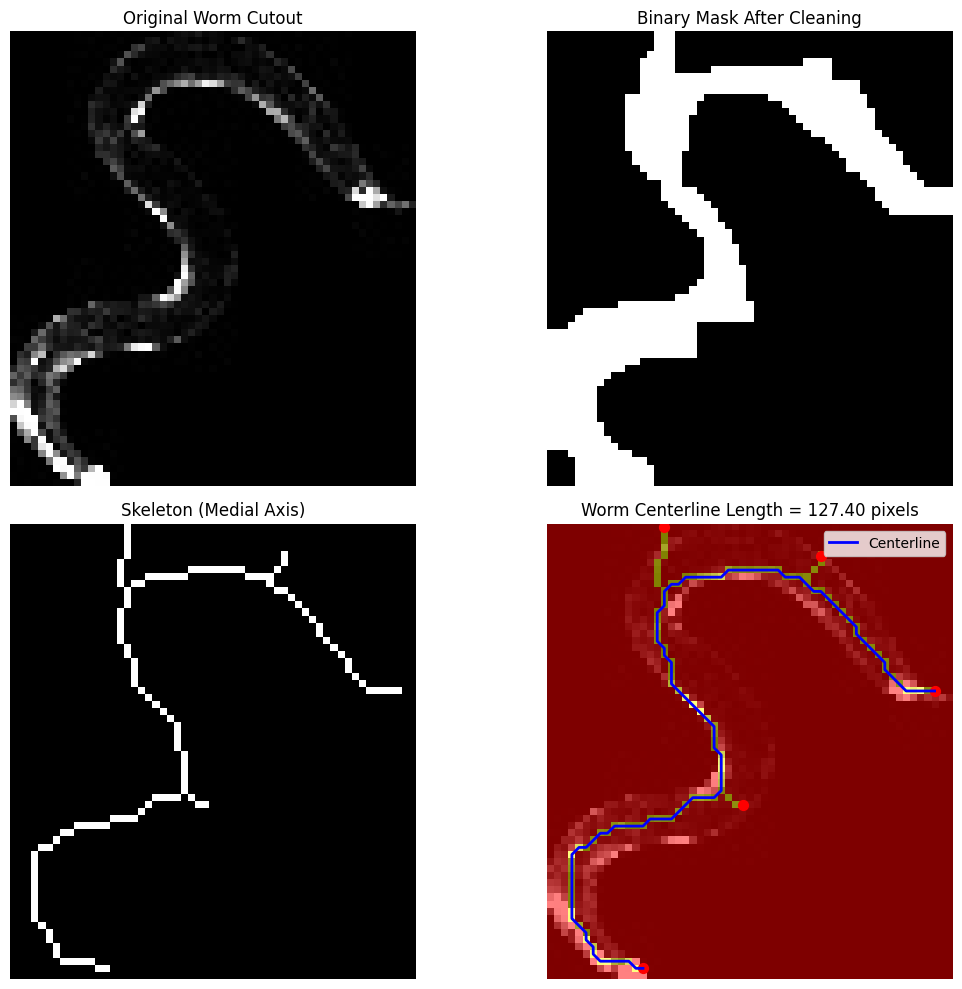

Centerline length for Worm 0: 127.40 pixels


In [21]:
# Creating a visualization for the first worm's length analysis (if available)
if len(worm_lengths) > 0:
    # Loading the first clean worm cutout
    first_cutout_file = image_cutouts_dir / '0.jpg'
    worm_image = cv2.imread(str(first_cutout_file))
    
    # Applying length determination to get all intermediate results
    length_result = determine_worm_length(worm_image)
    
    # Creating subplots for visualization
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Extracting components for visualization
    rgb_image = cv2.cvtColor(worm_image, cv2.COLOR_BGR2RGB)
    skeleton = length_result['skeleton']
    mask = length_result['mask']
    path_x = length_result['path_x']
    path_y = length_result['path_y']
    endpoints = length_result['endpoints']
    best_length = length_result['length']
    
    # Plot 1: Original image
    axes[0, 0].imshow(rgb_image)
    axes[0, 0].set_title('Original Worm Cutout')
    axes[0, 0].axis('off')
    
    # Plot 2: Binary mask
    axes[0, 1].imshow(mask, cmap='gray')
    axes[0, 1].set_title('Binary Mask After Cleaning')
    axes[0, 1].axis('off')
    
    # Plot 3: Skeleton
    axes[1, 0].imshow(skeleton, cmap='gray')
    axes[1, 0].set_title('Skeleton (Medial Axis)')
    axes[1, 0].axis('off')
    
    # Plot 4: Longest path with endpoints
    axes[1, 1].imshow(rgb_image)
    axes[1, 1].imshow(skeleton, cmap='autumn', alpha=0.5)
    if path_x is not None and path_y is not None:
        axes[1, 1].plot(path_x, path_y, linewidth=2, color='blue', label='Centerline')
    for r, c in endpoints:
        axes[1, 1].scatter(c, r, s=50, color='red', marker='o')
    axes[1, 1].set_title(f'Worm Centerline Length = {best_length:.2f} pixels')
    axes[1, 1].axis('off')
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"Centerline length for Worm 0: {best_length:.2f} pixels")
else:
    print("No worms to visualize")